In [31]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from Grape import GrapeLBFGS as gp
from Grape import *
from helpful_functions import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
def make_H(Nc: int, Nq: int, g: float, alpha: float) -> tuple[qt.Qobj, qt.Qobj]:
    """
    Build drift and control Hamiltonians for detuning control:

      H(t) = H_d + Δ(t) * H_c

    where:
      - H_d contains JC exchange + transmon Kerr anharmonicity
      - H_c is the transmon number operator n_q = a_q† a_q
    Tensor order: cavity ⊗ transmon.

    Returns:
      H_d, H_c
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    H_c = n_q
    return H_d, H_c


In [43]:
Nr_subspace_dim = 5          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq_subspace_dim = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 10     # total cavity dim: includes higher levels
Nq_big = 5      # total qubit dim: includes higher levels

g = 1 * 2*np.pi        # coupling (angular units)
alpha = -160 * 2*np.pi # transmon anharmonicity (angular units)
dressed_detuning = 140 * 2*np.pi  # detuning between cavity and transmon for adiabetic dressed frame 

drive_parameters = {
    'N_c': Nc_big,
    'N_q': Nq_big,   
    'detuning': dressed_detuning,  # qubit-resonator detuning in angular frequency
    'gbs': g,       # qubit-resonator coupling strength in angular frequency
}
results = dchi_H(drive_parameters, alpha)

evecs_qobj = results['sorted_dict']['evecs_qobj']
w_r_dressed = results['dressed_operators']['w_r_dressed']
w_q_dressed = results['dressed_operators']['w_q_dressed']
a_r_dressed = results['dressed_operators']['a_r']
a_q_dressed = results['dressed_operators']['a_q']

chi = results['chi_dict']['chi_list'][0]  # dispersive shift for 0->1 transition

a_r = results['Hamiltonian_dict']['a_r']
a_q = results['Hamiltonian_dict']['a_q']
n_r = a_r.dag() * a_r
n_q = a_q.dag() * a_q

H0_exact = results['Hamiltonian_dict']['H0']
H0_approx = w_r_dressed * a_r_dressed.dag() * a_r_dressed + w_q_dressed * a_q_dressed.dag() * a_q_dressed + chi * a_r_dressed.dag() * a_r_dressed * a_q_dressed.dag() * a_q_dressed

U_cross_target = (-1j * np.pi * (n_r * n_q)).expm() # this is the cross-Kerr needed

dressed_target = evecs_qobj * U_cross_target * evecs_qobj.dag() # target for dressed operators
gauge_ops = [evecs_qobj*n_r*evecs_qobj.dag(), evecs_qobj*n_q*evecs_qobj.dag()] # gauge ops for dressed frame
projector = projector_onto_states([results['sorted_dict']['evecs_sorted'][n_r][n_q] for n_r in range(Nr_subspace_dim) for n_q in range(Nq_subspace_dim)])

In [44]:
T_gate = np.pi/chi  # gate time for cross-Kerr pi. this is positive
f = unitary_projected_fidelity(dressed_target, ((1j*w_r_dressed * gauge_ops[0]*T_gate + 1j*w_q_dressed * gauge_ops[1]*T_gate).expm())*(-1j*H0_approx*T_gate).expm(), projector)
print(f)  # should be close to 1

f = unitary_projected_fidelity(dressed_target, ((1j*w_r_dressed * gauge_ops[0]*T_gate + 1j*w_q_dressed * gauge_ops[1]*T_gate).expm())*(-1j*H0_exact*T_gate).expm(), projector)
print(f)  # should be close to 1. exactly one if nq and nr subspaces are 2-level. as n_r increases fidelity drops. fidelity increases as the dressed detuning increases (better dispersive approx)
print(T_gate)

1.0000000000002693
0.9978359875081712
4.397197400384162


In [45]:
n_steps = 100
dt = T_gate / n_steps
det_min = 1.0 * 2*np.pi
det_max = 1000.0 * 2*np.pi

opt = gp(
    H_drift = make_H(Nc_big, Nq_big, g, alpha)[0],
    H_controls = [make_H(Nc_big, Nq_big, g, alpha)[1]],
    U_target = dressed_target,
    dt = dt,
    n_steps = n_steps,
    cost_type= "projected",
    projector = projector,
    derivative= "frechet",
    gauge_ops=gauge_ops
)

# opt.add_l2_amplitude_penalty(lam=1e-3)                          # discourage huge amplitudes
opt.add_smoothness_penalty(lam=1e-5)                            # encourage smooth pulses

pulses0 = dressed_detuning*np.ones((n_steps, 1)) # + 0.01*dressed_detuning*np.random.randn(n_steps, 1)  # initial pulse: constant detuning
theta0 = [w_r_dressed*T_gate, w_q_dressed*T_gate]

# pulses0, theta0 = load_pulses_theta("results/run1.npz")
options = {
        # <-- KEY ONE: make projected-gradient tolerance smaller => later termination
        "gtol": 1e-8,        # default is ~1e-5; try 1e-8, 1e-10, 1e-12

        # if you're stopping due to tiny objective improvements, tighten this too:
        "ftol": 1e-9,        # default ~2e-9; smaller => requires more improvement to stop

        # optional: allow more line-search steps per iteration
        "maxls": 50,
    }

out = opt.optimize(
    maxiter=50,
    pulse_bounds=[(det_min, det_max)],
    pulses0=pulses0,
    theta0 = theta0,
    scipy_options=options
) # initial fidelity is small need to fix something to start with ideal case

Fidelity: 0.9978359875080219
Fidelity: 0.9929700902662694
Fidelity: 0.998689857882692
Fidelity: 0.9988227779408253
Fidelity: 0.9991187859053852
Fidelity: 0.9991187928153294
Fidelity: 0.9991188187736195
Fidelity: 0.9991192137623612
Fidelity: 0.9991200269332667
Fidelity: 0.9991223709098058
Fidelity: 0.9991282413814102
Fidelity: 0.9991435201775851
Fidelity: 0.9991812917420358
Fidelity: 0.9992681112888872
Fidelity: 0.9994313632051395
Fidelity: 0.997813381725896
Fidelity: 0.9994477701834904
Fidelity: 0.9996406075565574
Fidelity: 0.9997512492053611
Fidelity: 0.9997725198636225
Fidelity: 0.999773799196448
Fidelity: 0.9997738189263522
Fidelity: 0.9997738190136696


Fidelity: 0.9997738190136696
Final fidelity: 0.9997738190136696


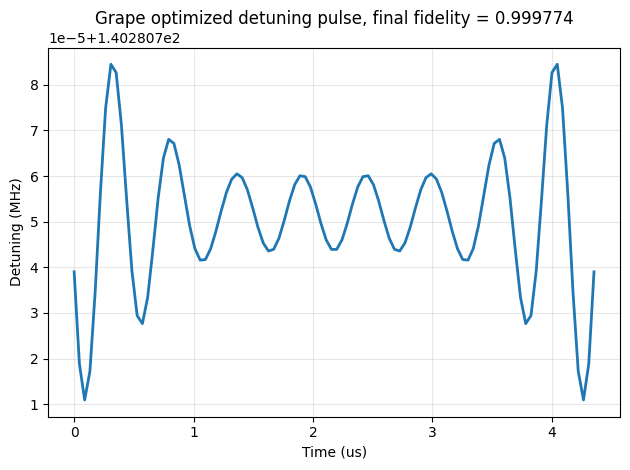

dressed_detuning (MHz): 140.0


In [46]:
# --- Final fidelity ---
F_final = opt.fidelity(out["pulses_opt"], theta=out["theta_opt"])
print("Final fidelity:", F_final)

t_us = np.arange(n_steps) * dt  # dt is in us in your codebase (T_gate/n_steps)
pulse_MHz = out["pulses_opt"][:, 0] / (2*np.pi)  # convert rad/ns -> MHz

plt.figure()
plt.plot(t_us, pulse_MHz, linewidth=2)

plt.xlabel("Time (us)")
plt.ylabel("Detuning (MHz)")
plt.title(f"Grape optimized detuning pulse, final fidelity = {F_final:.6f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("dressed_detuning (MHz):", dressed_detuning/(2*np.pi))

In [47]:
opt.save_results("Grape_results/run2.npz", out, extra_params={
    "dressed_detuning": dressed_detuning,
    "w_q_dressed": w_q_dressed,
})

In [48]:
q = load_qobjs("Grape_results/run2.npz")
pulses0, theta0 = load_pulses_theta("Grape_results/run2.npz")
parameters_dict = load_parameters_dict("Grape_results/run2.npz")

H0 = q["H_drift"]
Hc = q["H_controls"]
Ut = q["U_target"]
P  = q["projector"]
gauge_ops = q["gauge_ops"]

U_final = propagate(H0, Hc, dt = parameters_dict["dt"], pulses = pulses0)
G = gauge_unitary(gauge_ops, theta0)
g_unitary = G * U_final

# write unitary in terms of the dressed basis
# unitary_dressed = evecs_qobj.dag() * g_unitary * evecs_qobj

fidelity = unitary_projected_fidelity(Ut, g_unitary, P)
print("Fidelity check:", fidelity)

Fidelity check: 0.9997738190137091


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import Bloch
import ipywidgets as widgets
from ipywidgets import interact

# ── Load saved GRAPE pulse & operators ───────────────────────────
q_saved = load_qobjs("Grape_results/run1.npz")
p_grape, th_grape = load_pulses_theta("Grape_results/run1.npz")
p_dict  = load_parameters_dict("Grape_results/run1.npz")

H_drift_ev = q_saved["H_drift"]
H_ctrl_ev  = q_saved["H_controls"]

dt_ev               = p_dict["dt"]
dressed_detuning_ev = p_dict["dressed_detuning"]
w_q_dressed_ev      = p_dict["w_q_dressed"]
nsteps              = len(p_grape)

print(f"dressed_detuning = {dressed_detuning_ev / (2*np.pi):.4f} MHz")
print(f"w_q_dressed      = {w_q_dressed_ev      / (2*np.pi):.4f} MHz")

p_unopt = dressed_detuning_ev * np.ones((nsteps, 1))

# ── Qubit operators ───────────────────────────────────────────────
def _ket_bra(r, c, N):
    m = np.zeros((N, N), dtype=complex); m[r, c] = 1.0
    return qt.Qobj(m)

sx_q = _ket_bra(0, 1, Nq_big) + _ket_bra(1, 0, Nq_big)
sy_q = -1j * _ket_bra(0, 1, Nq_big) + 1j * _ket_bra(1, 0, Nq_big)
sz_q = _ket_bra(0, 0, Nq_big) - _ket_bra(1, 1, Nq_big)

sx_s = qt.tensor(qt.qeye(Nc_big), sx_q)
sy_s = qt.tensor(qt.qeye(Nc_big), sy_q)
sz_s = qt.tensor(qt.qeye(Nc_big), sz_q)

proj_01_s = qt.tensor(qt.qeye(Nc_big),
                      _ket_bra(0, 0, Nq_big) + _ket_bra(1, 1, Nq_big))

# ── Initial states: |n>_cav ⊗ |+x>_q  for n = 0..4 ──────────────
photon_nums = list(range(5))
psi0s = [
    qt.tensor(qt.basis(Nc_big, n),
              (qt.basis(Nq_big, 0) + qt.basis(Nq_big, 1)).unit())
    for n in photon_nums
]

# ── Step-by-step propagation ──────────────────────────────────────
def compute_bloch_trajectories(pulses, H_drift, H_ctrls, dt, psi0_list, label=""):
    """Returns bvec (n_states, n_steps+1, 3) and leakage (n_states, n_steps+1)."""
    ns = len(pulses)
    nb = len(psi0_list)
    bvec    = np.zeros((nb, ns + 1, 3))
    leakage = np.zeros((nb, ns + 1))
    psis = [p.copy() for p in psi0_list]

    for i, psi in enumerate(psis):
        bvec[i, 0] = [qt.expect(sx_s, psi).real,
                      qt.expect(sy_s, psi).real,
                      qt.expect(sz_s, psi).real]
        leakage[i, 0] = 1.0 - qt.expect(proj_01_s, psi).real

    for k in range(ns):
        H_k = H_drift + pulses[k, 0] * H_ctrls[0]
        U_k = (-1j * H_k * dt).expm()
        for i in range(nb):
            psis[i] = U_k * psis[i]
            bvec[i, k + 1] = [qt.expect(sx_s, psis[i]).real,
                               qt.expect(sy_s, psis[i]).real,
                               qt.expect(sz_s, psis[i]).real]
            leakage[i, k + 1] = 1.0 - qt.expect(proj_01_s, psis[i]).real
        if (k + 1) % 10 == 0:
            print(f"  {label} step {k+1}/{ns}", end="\r")
    print(f"  {label} done.            ")
    return bvec, leakage

print("Evolving GRAPE case…")
bv_grape, leak_grape = compute_bloch_trajectories(p_grape, H_drift_ev, H_ctrl_ev, dt_ev, psi0s, "GRAPE")
print("Evolving unoptimised case…")
bv_unopt, leak_unopt = compute_bloch_trajectories(p_unopt, H_drift_ev, H_ctrl_ev, dt_ev, psi0s, "Unopt")
print("All done.")

# ── Rotating-frame Bloch vectors (rotate out w_q_dressed) ────────
def to_rotating_frame(bvec, w_q, dt):
    t  = np.arange(bvec.shape[1]) * dt
    c, s = np.cos(w_q * t), np.sin(w_q * t)
    rf = bvec.copy()
    rf[:, :, 0] =  bvec[:, :, 0] * c + bvec[:, :, 1] * s
    rf[:, :, 1] = -bvec[:, :, 0] * s + bvec[:, :, 1] * c
    return rf

bv_grape_rf = to_rotating_frame(bv_grape, -w_q_dressed_ev, dt_ev)
bv_unopt_rf = to_rotating_frame(bv_unopt, -w_q_dressed_ev, dt_ev)

# ── Interactive Bloch sphere viewer ──────────────────────────────
frame_options = {
    'Lab frame':      (bv_grape,    bv_unopt),
    'Rotating frame': (bv_grape_rf, bv_unopt_rf),
}

def show_bloch(step, frame):
    bvecs_g, bvecs_u = frame_options[frame]
    cases = [("GRAPE optimised", bvecs_g), ("Unoptimised flat Δ", bvecs_u)]

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(f'{frame} — t = {step * dt_ev:.3f} μs  (step {step} / {nsteps})', fontsize=12)

    for row, (case_label, bvecs) in enumerate(cases):
        for col in range(5):
            ax = fig.add_subplot(2, 5, row * 5 + col + 1, projection='3d')
            b = Bloch(fig=fig, axes=ax)
            b.vector_color = ['tomato']
            b.point_color  = ['steelblue']
            b.point_marker = ['.']
            b.point_size   = [6]
            b.frame_alpha  = 0.05
            b.sphere_alpha = 0.05

            x = bvecs[col, :step + 1, 0]
            y = bvecs[col, :step + 1, 1]
            z = bvecs[col, :step + 1, 2]
            b.add_points([x, y, z], meth='l')
            b.add_vectors([float(x[-1]), float(y[-1]), float(z[-1])])
            b.make_sphere()

            title = f'n={col}' if row > 0 else f'{case_label}\nn={col}'
            ax.set_title(title, fontsize=8, pad=1)

    plt.tight_layout()
    plt.show()

interact(show_bloch,
         step=widgets.IntSlider(min=0, max=nsteps, step=1, value=0,
                                description='Step',
                                style={'description_width': 'initial'},
                                layout=widgets.Layout(width='70%')),
         frame=widgets.Dropdown(options=['Lab frame', 'Rotating frame'],
                                value='Lab frame',
                                description='Frame:'))


dressed_detuning = 152.0000 MHz
w_q_dressed      = 152.0066 MHz
Evolving GRAPE case…
  GRAPE done.            
Evolving unoptimised case…
  Unopt done.            
All done.


interactive(children=(IntSlider(value=0, description='Step', layout=Layout(width='70%'), style=SliderStyle(des…

<function __main__.show_bloch(step, frame)>

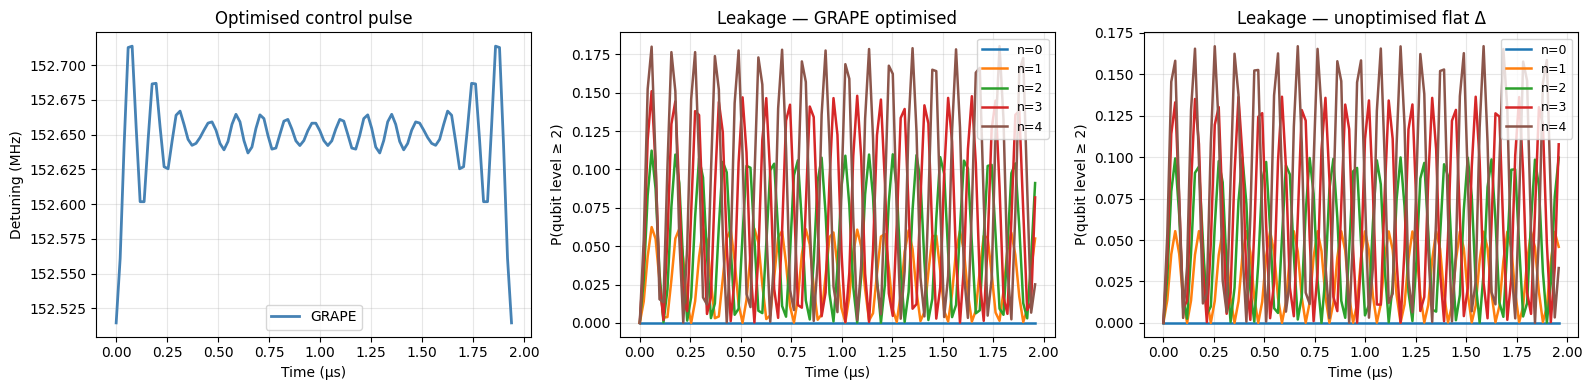

In [53]:

import matplotlib.pyplot as plt
import numpy as np

t_steps = np.arange(nsteps + 1) * dt_ev   # time axis for states (n_steps+1 points)
t_pulse = np.arange(nsteps) * dt_ev        # time axis for pulse  (n_steps points)

colors = plt.cm.tab10(np.linspace(0, 0.5, 5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Optimised pulse ───────────────────────────────────────────────
axes[0].plot(t_pulse, p_grape[:, 0] / (2 * np.pi), lw=2, color='steelblue', label='GRAPE')
# axes[0].axhline(dressed_detuning / (2 * np.pi), color='gray', lw=1.2,
#                 linestyle='--', label='flat Δ')
axes[0].set_xlabel('Time (μs)')
axes[0].set_ylabel('Detuning (MHz)')
axes[0].set_title('Optimised control pulse')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Leakage — GRAPE ───────────────────────────────────────────────
for n in photon_nums:
    axes[1].plot(t_steps, leak_grape[n], color=colors[n], lw=1.8, label=f'n={n}')
axes[1].set_xlabel('Time (μs)')
axes[1].set_ylabel('P(qubit level ≥ 2)')
axes[1].set_title('Leakage — GRAPE optimised')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Leakage — unoptimised ─────────────────────────────────────────
for n in photon_nums:
    axes[2].plot(t_steps, leak_unopt[n], color=colors[n], lw=1.8, label=f'n={n}')
axes[2].set_xlabel('Time (μs)')
axes[2].set_ylabel('P(qubit level ≥ 2)')
axes[2].set_title('Leakage — unoptimised flat Δ')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
